In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from numpy.linalg import svd,eig
import math
bPlot=False
bPlotEig=False
from HeatLearner import HeatLearner
HL = HeatLearner()


In [2]:
from HeatLearner import decompose_field, interp_temp, loadGinterpolants
from HeatLearner import pseudo_inverse_from_svd


In [3]:
HL.digest_fields()

In [4]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']



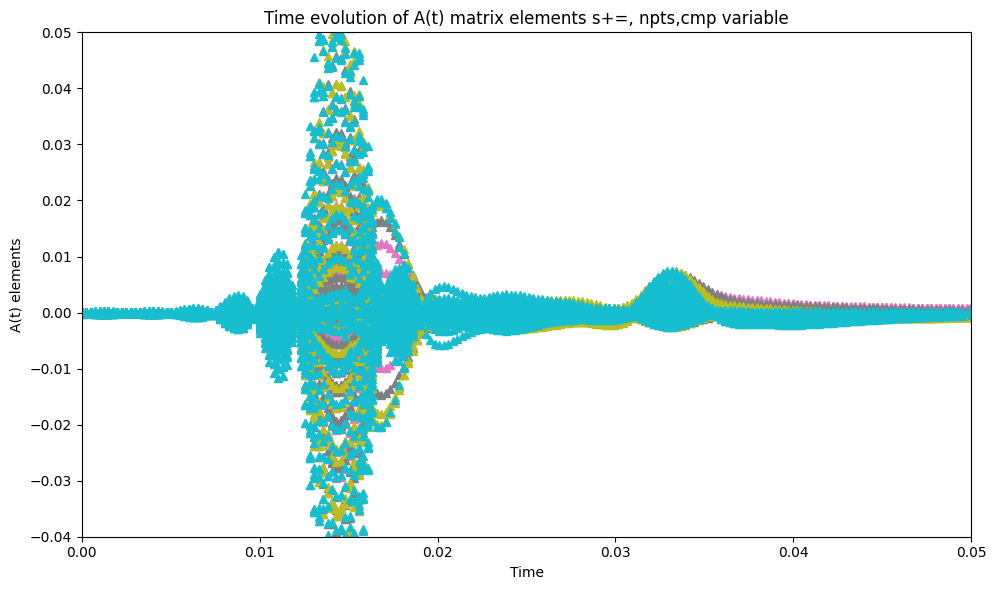

In [5]:
from bte_1d_boundaryfluxlearn import buildPropagators, plot_A_elements
buildPropagators(HL)
plot_A_elements(HL.prop,[ ([0.,0.05],'^'),
                        ([0.05,0.2],'o'),
                        ([0.2,HL.prop.t_list[-1]],'+') ])


In [10]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']



(13, 1) (13, 1)
(26,)


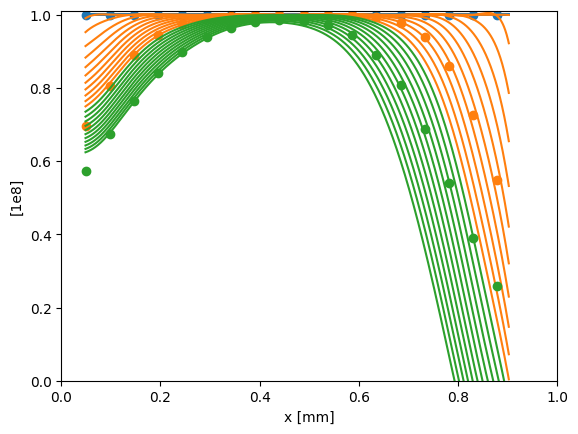

"        if False: #initial attempt to implement corrector. not sure why I was trying to do it within the epoch when I think by design I won't know Tavg except at epoch boundaries. I was having initial difficulties that I was attributing to integration errors and falsely though correctors were needed already. Final working prototype left the final line (c2+=Hp*(y-Hf)) commented and unused. but this workflow essential shows the chatGPT suggested process of distributing the error back into the coefficients by some operator Hp.\n            Hf = np.dot(H.T,c1[Nn,:])\n            norm = np.sqrt(np.dot(c1.T,c1)[0,0])\n            #print(norm)\n            y = (Navg-Navg_0)*(lTimes[i]-t_0)/(t-t_0)+Navg_0\n            #print(Hf,y,Hp.shape,c2.shape)\n            if False and i%10==0:\n                print(c1.T)\n            #print(y,Hf,Hp*(y-Hf))\n            '''if i==1:\n                break'''\n            Hp = c1/norm #This seems reasonable in that the magnitude of the current solution ve

In [11]:
from bte_1d_boundaryfluxlearn import integrate
integrate(HL)
"""        if False: #initial attempt to implement corrector. not sure why I was trying to do it within the epoch when I think by design I won't know Tavg except at epoch boundaries. I was having initial difficulties that I was attributing to integration errors and falsely though correctors were needed already. Final working prototype left the final line (c2+=Hp*(y-Hf)) commented and unused. but this workflow essential shows the chatGPT suggested process of distributing the error back into the coefficients by some operator Hp.
            Hf = np.dot(H.T,c1[Nn,:])
            norm = np.sqrt(np.dot(c1.T,c1)[0,0])
            #print(norm)
            y = (Navg-Navg_0)*(lTimes[i]-t_0)/(t-t_0)+Navg_0
            #print(Hf,y,Hp.shape,c2.shape)
            if False and i%10==0:
                print(c1.T)
            #print(y,Hf,Hp*(y-Hf))
            '''if i==1:
                break'''
            Hp = c1/norm #This seems reasonable in that the magnitude of the current solution vector elements should guide the distribution of the updates. Reasonable as first cut but not rigorous or empirically validated.
            #print(Hp)
            c1+=Hp*(y-Hf)
            #ChatGPT suggests this method under the idea that the vector update should be minimized.
            '''least-squares redistribution of measurement error:

            # Want minimal norm Δc so that H @ (c + Δc) = y_target
            # Δc = H^+ (y_target - H @ c)
            H_vec = H.ravel()   # shape (n_coeffs,)
            residual = (y_target - H_vec.dot(c))
            # pseudo-inverse for H: H^+ = H / (H.H) if H is vector
            Hp = H_vec / (H_vec.dot(H_vec) + 1e-12)
            delta_c = Hp * residual
            c_new = c + delta_c
            I do think this is too simplistic. It may develop oscillitory modes about the average.
            Other suggestions are minimizations of the update with hand tweaking. Another is Mahalanobis-style:
            Weighted (Mahalanobis) minimal-norm correction
            
            If you have prior knowledge of coefficient variances (covariance C), use
            \min \Delta c^T C^{-1} \Delta c\quad\text{s.t. } H\Delta c = r,
            leading to
            \Delta c = C H^T (H C H^T)^{-1} r.
            This will distribute correction across coefficients according to the covariance -- useful if some coefficients are known to be more trustworthy or you want to penalize changing high-frequency coefficients more strongly. An example snippet:
            import numpy as np
            
            # Suppose you have prior coefficient realizations: shape (N, n_c)
            C_samples = np.array([...])  # each row is c^(k)
            
            # Sample covariance
            C = np.cov(C_samples, rowvar=False)
            
            # Regularization with Ledoit–Wolf style that uses lambda to blend diagonal and off-diagonal to improve C condition.
            lam = 1e-6 * np.trace(C) / C.shape[0]
            C_reg = (1 - 0.1) * C + 0.1 * np.diag(np.diag(C)) + lam * np.eye(C.shape[0])
            
            # Then compute correction
            H = ...  # your measurement operator, shape (m, n_c)
            r = ...  # residual vector (y_target - H @ c_pred)
            
            Delta_c = C_reg @ H.T @ np.linalg.inv(H @ C_reg @ H.T) @ r'''
            
        c0=c1 #update c_i solutions
        if False and i%100==0:
            #print(c2.T)
            print(np.dot(H.T,c1[Nn,:]),y)"""
